# Perceptron - Construindo um classificador linear do zero

Perceptron é um fundamento de Redes Neurais Artificiais, proposto por Frank Rosenblatt em 1958, trata-se de um classificador binário que aprende a separar duas classes de dados encontrando a linha (hiperplano) que melhor divide o espaço de características.

## Dependências e Configurações

In [12]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print('\n - Bibliotecas carregadas - ')
print(f'Numpy      : {np.__version__}')
print(f'Matplotlib : {matplotlib.__version__}')


 - Bibliotecas carregadas - 
Numpy      : 2.1.3
Matplotlib : 3.10.0


## 1. Função de Ativação

O "cérebro" da decisão do Perceptron é a sua função de ativação. A soma ponderada das entradas nos dá um valor contínuo, mas precisamos converter isso em uma classe discreta (0 ou 1). A função utilizada é o **Degrau de Heaviside**:
*   Se $z \ge 0$, a saída é 1.
*   Se $z < 0$, a saída é 0.

Uso `np.where` do NumPy para garantir que essa função funcione tanto para um único valor quanto para um array inteiro de previsões (vetorização).

In [3]:
def heaviside(x):
    return np.where(x >= 0, 1, 0)

In [7]:
#testes
heaviside(1)

array(1)

In [8]:
heaviside(0)

array(1)

In [9]:
heaviside(-1)

array(0)

## 2. Inicialização e Previsão

Antes de aprender, o Perceptron precisa de uma estrutura base. Na classe:
*   **Pesos e Viés (Bias)**: Iniciados como zeros. O viés ajuda a deslocar a fronteira de decisão para longe da origem.
*   **Hiperparâmetros**: `learning_rate` (o tamanho do passo na atualização), `epochs` (quantas vezes veremos os dados), e `random_state` (para garantir reprodutibilidade).
*   **Previsão (`predict`)**: Calcula a soma ponderada $z = x \cdot w + b$ e aplica a função `heaviside`.

In [10]:
class Perceptron:

    def __init__(
        self,
        learning_rate=0.1,
        epochs=1000,
        verbose=False,
        log_every=10,
        random_state=None
    ):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.verbose = verbose
        self.log_every = log_every
        self.random_state = random_state

        self.weights = None
        self.bias = None

        self.errors = []
        self.accuracy_history = []

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return heaviside(linear_output)

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)

## 3. O Processo de Aprendizado (`fit`)

O método `fit` é onde a "mágica" acontece. O algoritmo passa pelos dados de treino época por época, cometendo erros e ajustando seus pesos. A regra de atualização é:
*   **Erro** = Valor Real ($y$) - Valor Previsto ($\hat{y}$)
*   **Ajuste dos Pesos** = $w_n = w_n + (\text{taxa de aprendizado} \times \text{erro} \times x_n)$

**Destaques:**
1.  **Embaralhamento (Shuffle):** A cada época, os dados são embaralhados. Isso evita que o modelo crie um viés de aprendizado dependendo da ordem em que as classes aparecem.
2.  **Otimização:** Os pesos só são atualizados se houver erro (`update != 0`), economizando processamento.
3.  **Histórico e Verbose:** Guardamos a acurácia e os erros por época para análise posterior e imprimimos o progresso se `verbose=True`.
4.  **Convergência Antecipada:** Se uma época inteira passar sem erros, o modelo aprendeu perfeitamente a separar os dados e o treino para.

## 4. Classe Final

In [11]:
class Perceptron:

    def __init__(self, learning_rate=0.1, epochs=1000, verbose=False, log_every=10, random_state=None):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.verbose = verbose
        self.log_every = log_every
        self.random_state = random_state

        self.weights = None
        self.bias = None
        self.errors = []
        self.accuracy_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        rng = np.random.RandomState(self.random_state)

        self.weights = np.zeros(n_features)
        self.bias = 0
        self.errors = []
        self.accuracy_history = []

        for epoch in range(self.epochs):
            erros_epoca = 0
            indices = rng.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for idx, x_i in enumerate(X_shuffled):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = 1 if linear_output >= 0 else 0

                update = self.learning_rate * (y_shuffled[idx] - y_predicted)

                if update != 0:
                    self.weights += update * x_i
                    self.bias += update
                    erros_epoca += 1

            self.errors.append(erros_epoca)
            accuracy = np.mean(self.predict(X) == y)
            self.accuracy_history.append(accuracy)

            if self.verbose and ((epoch + 1) % self.log_every == 0 or epoch == 0):
                print(f"Época: {epoch + 1:>4}/{self.epochs:<4} | Erros: {erros_epoca:>3} | Acurácia: {accuracy:>7.2%} | Bias: {self.bias:>8.4f}")

            if erros_epoca == 0:
                print(f"\nConvergência alcançada na época {epoch + 1}.")
                break

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return heaviside(linear_output)

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)

## 5. Testando e Visualizando o Treinamento (Porta Lógica AND)

Hora de testar o Perceptron com a porta lógica AND, com o atributo `verbose=True`, veremos o modelo aprendendo em tempo real. Com as listas `errors` e `accuracy_history` pode-se plotar a curva de aprendizado.

In [13]:
#dados de treino :: tabela verdade AND

X_treino = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_treino = np.array([0, 0, 0, 1])

X_treino, y_treino

(array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 array([0, 0, 0, 1]))

In [14]:
#instanciando o Perceptron com verbose
modelo_perceptron = Perceptron(
    learning_rate=0.2, 
    epochs=50, 
    verbose=True, 
    log_every=1, 
    random_state=42
)

#treinando o modelo
modelo_perceptron.fit(X_treino, y_treino)

Época:    1/50   | Erros:   4 | Acurácia:  75.00% | Bias:  -0.4000
Época:    2/50   | Erros:   2 | Acurácia:  75.00% | Bias:  -0.4000
Época:    3/50   | Erros:   2 | Acurácia: 100.00% | Bias:  -0.4000
Época:    4/50   | Erros:   0 | Acurácia: 100.00% | Bias:  -0.4000

Convergência alcançada na época 4.


In [15]:
#avaliando com o metodo score
acuracia_final = modelo_perceptron.score(X_treino, y_treino)
print(f"\nAcurácia final no treino: {acuracia_final:.2%}")


Acurácia final no treino: 100.00%


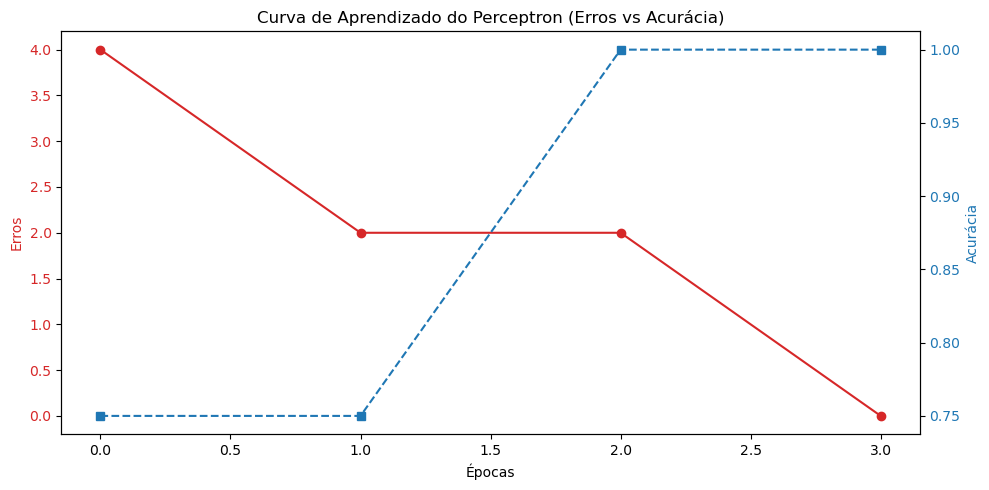

In [16]:
#visualizando a curva de aprendizado
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Erros', color=color)
ax1.plot(modelo_perceptron.errors, color=color, marker='o', label='Erros')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Acurácia', color=color)  
ax2.plot(modelo_perceptron.accuracy_history, color=color, marker='s', linestyle='--', label='Acurácia')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Curva de Aprendizado do Perceptron (Erros vs Acurácia)')
fig.tight_layout()  
plt.show()